Import Required Libraries

In [84]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

sns.set_style("whitegrid")

Load Dataset

In [85]:
df = pd.read_csv("/content/raw_crash_data.csv")

df.head()

,unique_id,case_id_fkey,latitude,longitude,collision_year,death_date,death_time,death_datetime,collision_date,collision_time,...,in_coc_2018,publish,on_vz_hin_2022,in_epa_2021,point,analysis_neighborhood,supervisor_district,police_district,data_as_of,data_loaded_at
0,1,140236301,37.710409,-122.404226,2014,2014/03/20,11:21:00,2014/03/20 11:21:00 AM,2014/03/20,NaN,...,False,True,True,False,POINT (-122.404226037 37.710409217),Bayview Hunters Point,10.0,INGLESIDE,2024/09/18 12:00:00 AM,2026/01/30 10:44:44 AM
1,2,140755533,37.725476,-122.394243,2014,2014/09/08,16:38:00,2014/09/08 04:38:00 PM,2014/09/08,05:10:00,...,True,True,True,True,POINT (-122.394243493 37.72547565),Bayview Hunters Point,10.0,BAYVIEW,2024/09/18 12:00:00 AM,2026/01/30 10:44:44 AM
2,4,140365546,37.748255,-122.413669,2014,2014/05/03,17:20:00,2014/05/03 05:20:00 PM,2014/05/03,02:24:00,...,False,True,True,False,POINT (-122.413668844 37.748255329),Mission,9.0,MISSION,2024/09/18 12:00:00 AM,2026/01/30 10:44:44 AM
3,16,150562049,37.777300,-122.419694,2015,2015/06/30,06:00:00,2015/06/30 06:00:00 AM,2015/06/28,03:52:00,...,False,True,True,True,POINT (-122.419693566 37.777299856),Tenderloin,5.0,NORTHERN,2024/09/18 12:00:00 AM,2026/01/30 10:44:44 AM
4,17,140104811,37.778251,-122.419883,2014,2014/02/06,10:20:00,2014/02/06 10:20:00 AM,2014/02/05,02:26:00,...,False,True,True,True,POINT (-122.419883231 37.778251017),Hayes Valley,5.0,NORTHERN,2024/09/18 12:00:00 AM,2026/01/30 10:44:44 AM


In [86]:
df.isnull().sum()

,0
unique_id,0
case_id_fkey,7
latitude,0
longitude,0
collision_year,0
death_date,0
death_time,35
death_datetime,0
collision_date,0
collision_time,25


In [87]:
# Remove rows with null values
df = df.dropna(subset=[
    'death_time',
    'collision_time',
    'age',
    'analysis_neighborhood',
    'supervisor_district',
    'data_as_of'
])

In [88]:
# Remove Duplicate Records
df = df.drop_duplicates()

In [89]:
# Convert Datetime Columns
df['collision_datetime'] = pd.to_datetime(df['collision_datetime'])
df['death_datetime'] = pd.to_datetime(df['death_datetime'])

/tmp/ipykernel_166/3149913693.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['death_datetime'] = pd.to_datetime(df['death_datetime'])


In [90]:
df['collision_hour'] = df['collision_datetime'].dt.hour
df['collision_day'] = df['collision_datetime'].dt.day_name()
df['collision_month'] = df['collision_datetime'].dt.month

In [92]:
# Handle Categorical Variables
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['collision_type'] = le.fit_transform(df['collision_type'])
df['street_type'] = le.fit_transform(df['street_type'])

In [93]:
# Select useful features for ML
features = df[['age','sex','collision_hour','collision_month',
               'collision_type','street_type','latitude','longitude']]

In [94]:
# Target variable
target = df['deceased']

Data Preparation for Machine Learning

In [95]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

Encode Categorical Variables

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    target,
    test_size=0.2,
    random_state=42
)

**Model 1 — Logistic Regression**

In [97]:
model = LogisticRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

Model Evaluation

In [98]:
# 1. Accuracy
accuracy_score(y_test, pred)

0.7457627118644068

In [100]:
# 2. Classification Report
print(classification_report(y_test, pred))

                              precision    recall  f1-score   support

                   Bicyclist       1.00      0.50      0.67         4
                      Driver       0.44      0.57      0.50         7
                Motorcyclist       0.62      0.71      0.67         7
                   Passenger       0.00      0.00      0.00         3
                  Pedestrian       0.82      0.97      0.89        34
Standup Powered Device Rider       0.00      0.00      0.00         4

                    accuracy                           0.75        59
                   macro avg       0.48      0.46      0.45        59
                weighted avg       0.67      0.75      0.70        59



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Model 2 — Random **Forest**

In [101]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [102]:
# 1. Accuracy
accuracy_score(y_test, pred_rf)

0.8135593220338984

In [103]:
# Confusion Matrix
confusion_matrix(y_test, pred_rf)

array([[ 3,  0,  0,  0,  1,  0],
       [ 0,  5,  1,  1,  0,  0],
       [ 0,  0,  7,  0,  0,  0],
       [ 0,  2,  0,  0,  1,  0],
       [ 0,  1,  0,  0, 33,  0],
       [ 0,  0,  0,  0,  4,  0]])

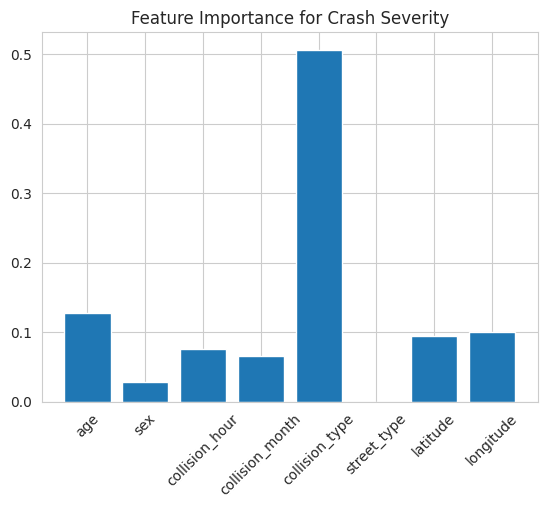

In [104]:
# Feature Importance

importance = rf.feature_importances_

plt.bar(features.columns, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance for Crash Severity")
plt.show()